In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import LinearSVC

import lightgbm as lgb
import joblib

from scipy.sparse import hstack

1. Incarcarea datelor

In [12]:
DATA_DIR = Path(".")

complaints_path = DATA_DIR / "complaints.csv"
safety_path = DATA_DIR / "safetygate_motor_vehicles.csv"

In [13]:
df_complaints = pd.read_csv(complaints_path)

In [14]:
df_safety = pd.read_csv(safety_path)

2. Curățarea datasetului NHTSA (complaints)

In [15]:
df_complaints.head()

,odiNumber,manufacturer,crash,fire,numberOfInjuries,numberOfDeaths,dateOfIncident,dateComplaintFiled,vin,components,summary,products,make,model,modelYear
0,10702705,"Kia America, Inc.",True,False,0,0,03/24/2015,03/30/2015,5XYPG4A36GG,"SEAT BELTS,SEATS",SEAT BELT DID NOT UNLATCH AFTER CRASH. *TR,"[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",KIA,SORENTO,2016
1,10713088,"Kia America, Inc.",False,False,0,0,04/24/2015,04/27/2015,5XYPH4A15GG,STRUCTURE,"TRAVELING AT HIGHWAY SPEED, THE WINDSHIELD SEE...","[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",KIA,SORENTO,2016
2,10713503,"ALUMA TOWER COMPANY, INC",False,True,0,0,04/28/2015,04/29/2015,1YGAE1629GB,ELECTRICAL SYSTEM,TL* THE CONTACT OWNS A 2016 ALUMA AE716TA TRAI...,"[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",ALUMA,AE716TA,2016
3,10715078,"Kia America, Inc.",False,False,0,0,04/30/2015,05/07/2015,NaN,STEERING,"WHILE TRAVELING AT HIGHWAY SPEEDS, THE SORENTO...","[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",KIA,SORENTO,2016
4,10715844,Volvo Trucks North America,False,False,0,0,03/06/2015,05/12/2015,4V4NC9EH7GN,SUSPENSION,SINCE THE PURCHASE OF THIS VEHICLE IT HAS AN U...,"[{""type"": ""Vehicle"", ""productYear"": ""2016"", ""p...",VOLVO,780,2016


In [ ]:
df_complaints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237700 entries, 0 to 237699
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   odiNumber           237700 non-null  int64 
 1   manufacturer        237682 non-null  object
 2   crash               237700 non-null  bool  
 3   fire                237700 non-null  bool  
 4   numberOfInjuries    237700 non-null  int64 
 5   numberOfDeaths      237700 non-null  int64 
 6   dateOfIncident      237700 non-null  object
 7   dateComplaintFiled  237700 non-null  object
 8   vin                 232524 non-null  object
 9   components          237690 non-null  object
 10  summary             237689 non-null  object
 11  products            237700 non-null  object
 12  make                237700 non-null  object
 13  model               237700 non-null  object
 14  modelYear           237700 non-null  int64 
dtypes: bool(2), int64(4), object(9)
memory usage: 24.0+

In [ ]:
df_complaints.isnull().sum().sort_values(ascending=False)

,0
vin,5176
manufacturer,18
summary,11
components,10
fire,0
odiNumber,0
crash,0
dateOfIncident,0
numberOfDeaths,0
numberOfInjuries,0


In [16]:
df_complaints = df_complaints.drop(columns=["vin", "odiNumber"], errors="ignore")

In [17]:
df_complaints = df_complaints.dropna(subset=["summary", "components"]).copy()

In [18]:
df_complaints = df_complaints.reset_index(drop=True)

In [19]:
df_complaints.isnull().sum().sort_values(ascending=False)

,0
manufacturer,8
crash,0
fire,0
numberOfInjuries,0
numberOfDeaths,0
dateOfIncident,0
dateComplaintFiled,0
components,0
summary,0
products,0


In [20]:
print(df_complaints.shape)

(237679, 13)


In [21]:
print(df_complaints[["summary", "components"]].isna().sum())

summary       0
components    0
dtype: int64


3. Curățarea datasetului Safety Gate (alerts)

In [23]:
df_safety.head()

,Type of alert,Type,Country of origin,Risk type,Risk legal provision,Product,Name,Description,Brand,Category,Type / number of model,Risk,Compulsory measures,Voluntary measures,Company recall page,Production dates (**)
0,Serious risk,Consumer,Sweden,Injuries,The mounting screws of the A-pillar trim may b...,Passenger car,"S60, V60",Passenger car.\r\n\r\n\r\n,Volvo,Motor vehicles,"Type: F model: S60, V60 EC type-approval: e9*2...",NaN,NaN,Type of economic operator taking notified meas...,NaN,NaN
1,Serious risk,Consumer,Germany,Injuries,The product poses a risk of injuries as there ...,Passenger car,X5,Passenger car\r\n\r\n\r\n,Bmw,Motor vehicles,"Models X5 Xdrive 3.0d, X6 Xdrive 3.5d and X6 X...",NaN,NaN,Type of economic operator taking notified meas...,NaN,NaN
2,Serious risk,Consumer,Germany,Injuries,"On long journeys at constant, very high engine...",Motor cycles,"K1300S, K1300R",Motorcycle\r\n\r\n\r\n,Bmw,Motor vehicles,"Type: K12S, sales designations: K1300S, K1300R...",NaN,NaN,Type of economic operator taking notified meas...,NaN,NaN
3,Serious risk,Consumer,Czechia,Injuries,In extreme operating conditions there can be a...,Motorcycle tyre,DOT,Motorcycle tyre\r\n\r\n\r\n,Mitas,Motor vehicles,"\r\n• 110/80-19 M / C 59T E-07 TL MI, article ...",NaN,NaN,NaN,NaN,NaN
4,Serious risk,Consumer,Slovakia,Injuries,The handbrake may not release fully. Inappropr...,Passenger car,Picanto,Passenger car.\r\n\r\n\r\n,Kia,Motor vehicles,PICANTO (MT) produced before 29-03-2012.\r\n\r...,NaN,NaN,Type of economic operator taking notified meas...,NaN,NaN


In [24]:
df_safety.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4438 entries, 0 to 4437
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Type of alert           4438 non-null   object
 1   Type                    4438 non-null   object
 2   Country of origin       4438 non-null   object
 3   Risk type               4438 non-null   object
 4   Risk legal provision    4416 non-null   object
 5   Product                 4438 non-null   object
 6   Name                    4390 non-null   object
 7   Description             4437 non-null   object
 8   Brand                   4431 non-null   object
 9   Category                4438 non-null   object
 10  Type / number of model  4259 non-null   object
 11  Risk                    3152 non-null   object
 12  Compulsory measures     68 non-null     object
 13  Voluntary measures      4357 non-null   object
 14  Company recall page     546 non-null    object
 15  Prod

In [25]:
df_safety.isnull().sum().sort_values(ascending=False)

,0
Compulsory measures,4370
Company recall page,3892
Risk,1286
Production dates (**),187
Type / number of model,179
Voluntary measures,81
Name,48
Risk legal provision,22
Brand,7
Description,1


In [22]:
df_safety = df_safety.drop(
    columns=[
        "Barcode",
        "Batch number",
        "Packaging description",
        "Company recall code (**)",
        "Products were found and measures were taken also in",
        "OECD Portal category",
        "Alert number",
        "Alert submitted by",
        "Counterfeit",
        "URL of Case"
    ],
    errors="ignore"
).copy()

df_safety = df_safety.reset_index(drop=True)

In [26]:
df_safety.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4438 entries, 0 to 4437
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Type of alert           4438 non-null   object
 1   Type                    4438 non-null   object
 2   Country of origin       4438 non-null   object
 3   Risk type               4438 non-null   object
 4   Risk legal provision    4416 non-null   object
 5   Product                 4438 non-null   object
 6   Name                    4390 non-null   object
 7   Description             4437 non-null   object
 8   Brand                   4431 non-null   object
 9   Category                4438 non-null   object
 10  Type / number of model  4259 non-null   object
 11  Risk                    3152 non-null   object
 12  Compulsory measures     68 non-null     object
 13  Voluntary measures      4357 non-null   object
 14  Company recall page     546 non-null    object
 15  Prod

In [27]:
print(df_safety.shape)

(4438, 16)


In [28]:
print(df_safety.isnull().sum().sort_values(ascending=False).head(10))

Compulsory measures       4370
Company recall page       3892
Risk                      1286
Production dates (**)      187
Type / number of model     179
Voluntary measures          81
Name                        48
Risk legal provision        22
Brand                        7
Description                  1
dtype: int64


4. Pregătirea variabilelor (feature engineering)

4.1. NHTSA - Complaints

In [29]:
df_complaints_renamed = df_complaints.rename(columns={
    "summary": "text",
    "components": "system"
}).copy()

In [30]:
df_complaints_renamed["text"] = df_complaints_renamed["text"].fillna("")
df_complaints_renamed["system"] = df_complaints_renamed["system"].fillna("")
df_complaints_renamed["fire_flag"] = df_complaints_renamed["fire"].fillna(False).astype(bool)
df_complaints_renamed["compulsory_flag"] = 0
df_complaints_renamed["source"] = "complaint"
df_complaints_renamed["risk_label"] = 0   # nu sunt alerte oficiale

4.2. EU Safety Gate - Alerte

In [31]:
df_safety_renamed = df_safety.rename(columns={
    "Product": "system",
    "Risk type": "risk_type",
    "Risk": "risk_text"
}).copy()

In [32]:
df_safety_renamed["text"] = (
    df_safety_renamed["Risk legal provision"].fillna("") + " " +
    df_safety_renamed["risk_type"].fillna("") + " " +
    df_safety_renamed["risk_text"].fillna("")
).str.replace(r"\s+", " ", regex=True).str.strip()

In [34]:
df_safety_renamed["system"] = df_safety_renamed["system"].fillna("")

In [35]:
df_safety_renamed["compulsory_flag"] = df_safety_renamed["Compulsory measures"].notna().astype(int)

In [36]:
df_safety_renamed["fire_flag"] = df_safety_renamed["text"].str.contains(r"\bfire\b", case=False, na=False)

In [37]:
df_safety_renamed["source"] = "safety_alert"

In [38]:
df_safety_renamed["risk_label"] = 1

5. Construirea datasetului final

In [39]:
common_cols = [
    "text",
    "system",
    "fire_flag",
    "compulsory_flag",
    "source",
    "risk_label"
]

In [40]:
complaints_final = df_complaints_renamed[common_cols]

In [41]:
safety_final = df_safety_renamed[common_cols]

In [42]:
full_dataset = pd.concat([complaints_final, safety_final], axis=0).reset_index(drop=True)

6. Verificarea datasetului final

In [43]:
print(full_dataset.head())

                                                text             system  \
0        SEAT BELT DID NOT UNLATCH AFTER CRASH.  *TR   SEAT BELTS,SEATS   
1  TRAVELING AT HIGHWAY SPEED, THE WINDSHIELD SEE...          STRUCTURE   
2  TL* THE CONTACT OWNS A 2016 ALUMA AE716TA TRAI...  ELECTRICAL SYSTEM   
3  WHILE TRAVELING AT HIGHWAY SPEEDS, THE SORENTO...           STEERING   
4  SINCE THE PURCHASE OF THIS VEHICLE IT HAS AN U...         SUSPENSION   

   fire_flag  compulsory_flag     source  risk_label  
0      False                0  complaint           0  
1      False                0  complaint           0  
2       True                0  complaint           0  
3      False                0  complaint           0  
4      False                0  complaint           0  


In [46]:
print("\nDistribuție risk_label:")
print(full_dataset["risk_label"].value_counts())


Distribuție risk_label:
risk_label
0    237679
1      4438
Name: count, dtype: int64


In [47]:
print("\nDistribuție compulsory_flag:")
print(full_dataset["compulsory_flag"].value_counts())


Distribuție compulsory_flag:
compulsory_flag
0    242049
1        68
Name: count, dtype: int64


In [48]:
print("\nExemple text din clasa 1:")
print(full_dataset.loc[full_dataset["risk_label"] == 1, "text"].head())


Exemple text din clasa 1:
237679    The mounting screws of the A-pillar trim may b...
237680    The product poses a risk of injuries as there ...
237681    On long journeys at constant, very high engine...
237682    In extreme operating conditions there can be a...
237683    The handbrake may not release fully. Inappropr...
Name: text, dtype: object


7. Analiza distribuției claselor în dataset
-*Dezechilibrul dintre reclamații și alerte oficiale*



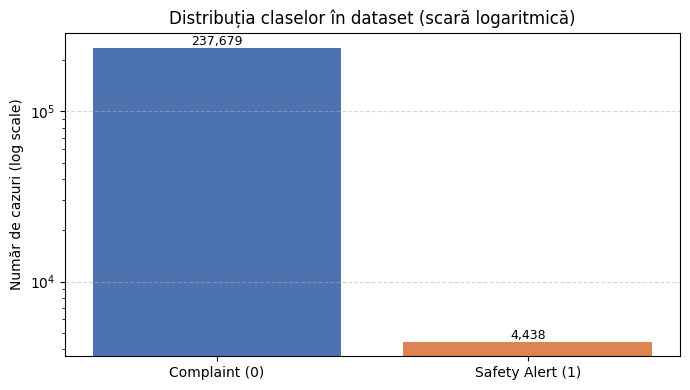

In [51]:
class_counts = full_dataset["risk_label"].value_counts().sort_index()

labels = ["Complaint (0)", "Safety Alert (1)"]
values = class_counts.values
colors = ["#4C72B0", "#DD8452"]  # albastru / portocaliu discret

plt.figure(figsize=(7,4))
bars = plt.bar(labels, values, color=colors)

plt.yscale("log")  # scară logaritmică
plt.title("Distribuția claselor în dataset (scară logaritmică)")
plt.ylabel("Număr de cazuri (log scale)")

# afișăm valorile deasupra barelor
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# MODELARE — PIPELINE PRINCIPAL

8. Model de bază: Logistic Regression (vectorizarea textului folosind TF-IDF)



In [52]:
tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2)
)

In [59]:
# matrice sparse cu TF-IDF pentru fiecare rând din dataset / document
X_text = tfidf.fit_transform(full_dataset["text"].fillna(""))

In [60]:
# vectorul etichetelor: 0 = complaint, 1 = safety alert
y = full_dataset["risk_label"].values

9. Împărțirea datelor în train și test
păstrând distribuția claselor (stratified split) (stratify=y)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [55]:
print("Distribuția claselor în y:")
print(pd.Series(y).value_counts(normalize=True))

Distribuția claselor în y:
0    0.98167
1    0.01833
Name: proportion, dtype: float64


In [57]:
print("\nDistribuția claselor în y_train:")
print(pd.Series(y_train).value_counts(normalize=True))


Distribuția claselor în y_train:
0    0.981672
1    0.018328
Name: proportion, dtype: float64


In [58]:
print("\nDistribuția claselor în y_test:")
print(pd.Series(y_test).value_counts(normalize=True))


Distribuția claselor în y_test:
0    0.981662
1    0.018338
Name: proportion, dtype: float64


10. Model de bază: Logistic Regression

In [62]:
# class_weight="balanced" compensează dezechilibrul dintre clase
lr_text_only = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

In [63]:
lr_text_only.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000)

In [64]:
y_pred = lr_text_only.predict(X_test)

11. Evaluarea performantei modelului



In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.96      0.99      0.98       888

    accuracy                           1.00     48424
   macro avg       0.98      1.00      0.99     48424
weighted avg       1.00      1.00      1.00     48424



Matricea de confuzie

In [87]:
cm = confusion_matrix(y_test, y_pred)

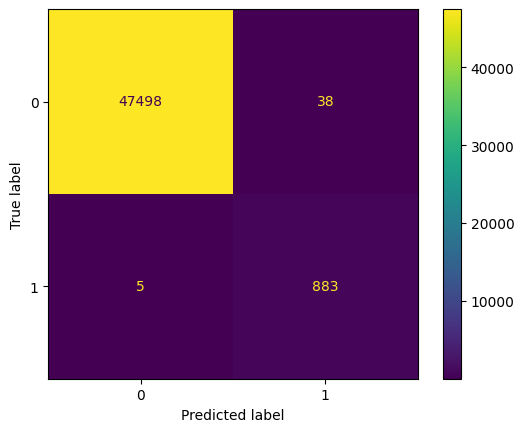

In [92]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

12. Interpretarea modelului: termeni asociați riscului de recall

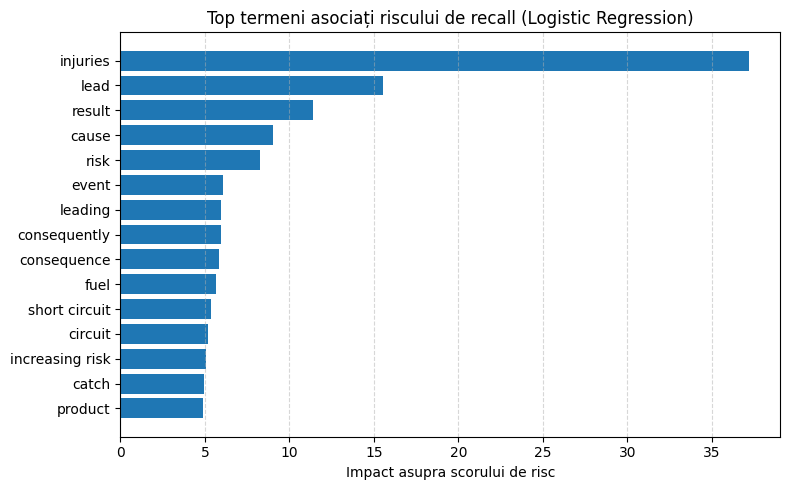

In [66]:
# Extragem coeficienții Logistic Regression
feature_names = tfidf.get_feature_names_out()
coefficients = lr_text_only.coef_[0]

coef_df = pd.DataFrame({
    "term": feature_names,
    "coef": coefficients
})

# Selectăm top N termeni cu impact pozitiv (risc mai mare)
TOP_N = 15
top_risk_terms = coef_df.sort_values("coef", ascending=False).head(TOP_N)

plt.figure(figsize=(8,5))
plt.barh(
    top_risk_terms["term"],
    top_risk_terms["coef"]
)

plt.xlabel("Impact asupra scorului de risc")
plt.title("Top termeni asociați riscului de recall (Logistic Regression)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

13. Rafinarea interpretării: eliminarea termenilor generici

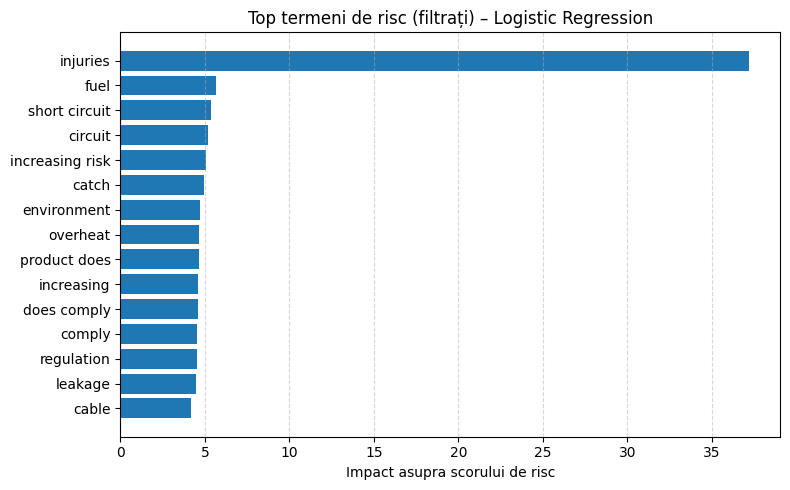

In [67]:
# 1) Extragem coeficienții ca înainte
feature_names = tfidf.get_feature_names_out()
coefficients = lr_text_only.coef_[0]

coef_df = pd.DataFrame({
    "term": feature_names,
    "coef": coefficients
})

# 2) Listă de termeni generici (poți adăuga/șterge după gust)
generic_terms = {
    "product", "result", "results", "cause", "causes", "risk",
    "lead", "leads", "leading", "event", "consequence", "consequently",
    "may", "could", "possible", "potential", "likely"
}

# 3) Filtrăm: păstrăm doar termeni care NU sunt generici
# (și păstrăm doar coeficienți pozitivi – semnale de risc)
coef_filtered = coef_df[
    (coef_df["coef"] > 0) &
    (~coef_df["term"].isin(generic_terms))
].copy()

# 4) Top N după filtrare
TOP_N = 15
top_risk_terms_filtered = coef_filtered.sort_values("coef", ascending=False).head(TOP_N)

# 5) Plot
plt.figure(figsize=(8,5))
plt.barh(top_risk_terms_filtered["term"], top_risk_terms_filtered["coef"])
plt.xlabel("Impact asupra scorului de risc")
plt.title("Top termeni de risc (filtrați) – Logistic Regression")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [68]:
y_proba = lr_text_only.predict_proba(X_test)[:, 1]

Analiza performanței modelului — ROC Curve și AUC

In [98]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [100]:
auc_score = roc_auc_score(y_test, y_proba)

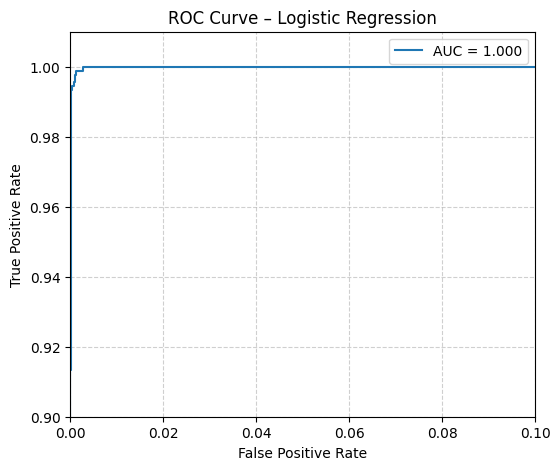

In [106]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="orange", alpha=0.7)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.grid()

plt.xlim(0, 0.1)
plt.ylim(0.9, 1.01)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

Observație privind performanța modelului:
*Curba ROC indică o separare aproape perfectă între clase (AUC ≈ 1.0).
Acest rezultat este influențat și de natura datasetului, deoarece textele provenite din reclamații (NHTSA) și cele din alerte oficiale (Safety Gate) au stiluri lingvistice diferite.
În consecință, modelul poate identifica relativ ușor diferențe între cele două tipuri de documente.*

14. Ajustarea pragului de decizie (decision threshold)

In [69]:
for threshold in [0.5, 0.3, 0.2]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(f"\n=== Threshold = {threshold} ===")
    print(classification_report(y_test, y_pred_thresh))


=== Threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.96      0.99      0.98       888

    accuracy                           1.00     48424
   macro avg       0.98      1.00      0.99     48424
weighted avg       1.00      1.00      1.00     48424


=== Threshold = 0.3 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.93      1.00      0.96       888

    accuracy                           1.00     48424
   macro avg       0.96      1.00      0.98     48424
weighted avg       1.00      1.00      1.00     48424


=== Threshold = 0.2 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.87      1.00      0.93       888

    accuracy                           1.00     48424
   macro avg       0.94      1.00      0.97     48424

15. Alegerea pragului final (strategie orientată spre siguranță)

In [70]:
FINAL_THRESHOLD = 0.2

Predicții finale pe setul de test

In [71]:
y_pred_final = (y_proba >= FINAL_THRESHOLD).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.87      1.00      0.93       888

    accuracy                           1.00     48424
   macro avg       0.94      1.00      0.97     48424
weighted avg       1.00      1.00      1.00     48424



In [93]:
cm_final = confusion_matrix(y_test, y_pred_final)

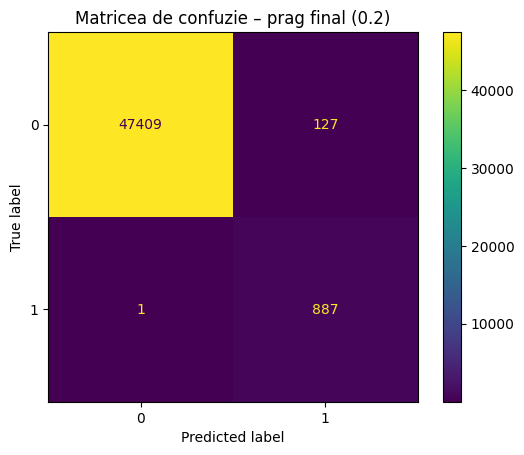

In [95]:
ConfusionMatrixDisplay(confusion_matrix=cm_final).plot()
plt.title("Matricea de confuzie – prag final (0.2)")
plt.show()

JUSTIFICAREA PRAGULUI ALES
*Această abordare reduce probabilitatea de a rata o alertă reală (false negative), chiar dacă duce la creșterea numărului de alarme false (false positive).
În contextul siguranței auto, o astfel de strategie „safety-first” este preferabilă, deoarece ratarea unui risc real poate avea consecințe mult mai grave decât investigarea unor alarme suplimentare.*

# MODELE ALTERNATIVE

16. Model alternativ: Linear SVC

In [72]:
# LinearSVC nu are predict_proba, dar e excelent pe TF-IDF
svc = LinearSVC(class_weight="balanced", random_state=42)

In [73]:
# Train
svc.fit(X_train, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [74]:
# Predict
y_pred_svc = svc.predict(X_test)

In [75]:
# Report
print("=== Linear SVC (balanced) ===")
print(classification_report(y_test, y_pred_svc))

=== Linear SVC (balanced) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.99      0.99      0.99       888

    accuracy                           1.00     48424
   macro avg       1.00      1.00      1.00     48424
weighted avg       1.00      1.00      1.00     48424



17. Model alternativ Gradient Boosting: LightGBM

In [84]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

In [82]:
lgbm_fast = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    num_leaves=31,
    min_data_in_leaf=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

In [78]:
lgbm_fast.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 3550, number of negative: 190143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 232.665871 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1775624
[LightGBM] [Info] Number of data points in the train set: 193693, number of used features: 25370
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018328 -> initscore=-3.980829
[LightGBM] [Info] Start training from score -3.980829


LGBMClassifier(colsample_bytree=0.8, min_data_in_leaf=50, n_estimators=150,
               n_jobs=-1, random_state=42,
               scale_pos_weight=np.float64(53.56140845070423), subsample=0.8)

In [79]:
y_pred_lgbm = lgbm_fast.predict(X_test)

print("=== LightGBM (FAST) ===")
print(classification_report(y_test, y_pred_lgbm))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
=== LightGBM (FAST) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47536
           1       0.98      0.99      0.99       888

    accuracy                           1.00     48424
   macro avg       0.99      1.00      0.99     48424
weighted avg       1.00      1.00      1.00     48424



Concluzii privind performanța modelelor

Au fost testate trei modele de clasificare: Logistic Regression, Linear SVC și LightGBM.
Toate modelele au obținut performanțe foarte ridicate pe setul de test, cu valori apropiate de 1 pentru precizie, recall și AUC.

Modelul Logistic Regression a fost ales ca model final datorită simplității, interpretabilității și stabilității sale pe date de tip TF-IDF.

Pentru a reduce riscul de a rata alerte reale, pragul de decizie a fost ajustat la 0.2, adoptând o strategie orientată spre siguranță („safety-first”), care prioritizează detectarea potențialelor cazuri de risc.

# SALVAREA MODELULUI

18. Salvarea modelelor antrenate

In [102]:
bundle_lr = {
    "model": lr_text_only,
    "tfidf": tfidf,
    "threshold": FINAL_THRESHOLD
}

joblib.dump(bundle_lr, "recall_risk_lr_bundle.joblib")
print("Saved: recall_risk_lr_bundle.joblib")

Saved: recall_risk_lr_bundle.joblib


In [103]:
bundle_svc = {
    "model": svc,          # Linear SVC antrenat
    "tfidf": tfidf,        # același TF-IDF
    "notes": "LinearSVC(class_weight='balanced'), text-only TF-IDF"
}

joblib.dump(bundle_svc, "recall_risk_svc_bundle.joblib")
print("Saved: recall_risk_svc_bundle.joblib")

Saved: recall_risk_svc_bundle.joblib


# DEMO

19. Demonstrație: predictor interactiv al riscului de recall

In [107]:
bundle = joblib.load("recall_risk_lr_bundle.joblib")
model = bundle["model"]
tfidf = bundle["tfidf"]
threshold = bundle["threshold"]

while True:
    user_text = input("Descriere defect (sau 'exit'): ").strip()
    if user_text.lower() == "exit":
        break

    X_input = tfidf.transform([user_text])
    proba = model.predict_proba(X_input)[0, 1]
    pred = int(proba >= threshold)

    verdict = "ALERTĂ (posibil recall)" if pred == 1 else "reclamație obișnuită"
    print(f"→ Verdict: {verdict} | P(alertă)= {proba:.3f}\n")

Descriere defect (sau 'exit'): exit


20. Extensie opțională: extragerea vocabularului de risc

In [ ]:
# (OPȚIONAL) MODEL 2: „danger_vocabulary” + NUMERICE (doar dacă vrei să revii)
# Notă: trebuie să definești X_numeric înainte de hstack.
# from scipy.sparse import hstack  # (pentru varianta cu X_numeric)
# ------------------------
# alerts_text = full_dataset.loc[full_dataset["risk_label"] == 1, "text"].fillna("")
# tfidf_alerts = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.7, ngram_range=(1,2))
# tfidf_alerts.fit(alerts_text)
# danger_vocabulary = tfidf_alerts.get_feature_names_out()
# print(f"Număr termeni danger_vocabulary: {len(danger_vocabulary)}")
#
# tfidf_full = TfidfVectorizer(vocabulary=danger_vocabulary)
# X_text2 = tfidf_full.fit_transform(full_dataset["text"].fillna(""))
#
# # Exemplu numeric (dacă îl vrei): fire_flag + compulsory_flag
# X_numeric = full_dataset[["fire_flag", "compulsory_flag"]].astype(int).values
#
# X2 = hstack([X_text2, X_numeric])
# y2 = full_dataset["risk_label"].values
#
# X_train2, X_test2, y_train2, y_test2 = train_test_split(
#     X2, y2, test_size=0.2, stratify=y2, random_state=42
# )
#
# lr2 = LogisticRegression(max_iter=3000, class_weight="balanced")
# lr2.fit(X_train2, y_train2)
# y_pred2 = lr2.predict(X_test2)
# print(classification_report(y_test2, y_pred2))

In [110]:
!ls

complaints.csv	recall_risk_lr_bundle.joblib   safetygate_motor_vehicles.csv
drive		recall_risk_svc_bundle.joblib  sample_data


In [114]:
import os
os.listdir()

['.config',
 'drive',
 '.ipynb_checkpoints',
 'recall_risk_lr_bundle.joblib',
 'complaints.csv',
 'safetygate_motor_vehicles.csv',
 'recall_risk_svc_bundle.joblib',
 'sample_data']

In [111]:
from google.colab import files

files.download("recall_risk_lr_bundle.joblib")
files.download("recall_risk_svc_bundle.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
import shutil

shutil.copy(
    "Draft_proiect_final_2025.ipynb",
    "/content/drive/MyDrive/Draft_proiect_final_2025.ipynb"
)

FileNotFoundError: [Errno 2] No such file or directory: 'Draft_proiect_final_2025.ipynb'